# **Translator V2 Training Notebook**<br>

## **1.** Classified Opensub Dataset Upload

In [1]:
import sys, pickle
import pandas as pd
sys.path.append('../modules')
from BPE_tokenizer import tokenize_eng, tokenize_pol, get_unique_freqs, BPETokenizer, BPEEncoder
import Data, Model_ref, Trainer, Predict
from collections import Counter
from tqdm.auto import tqdm
tqdm.pandas()


In [2]:
with open("../local_data/translator_v2/data_final_opensub.pkl", 'rb') as f:
    df_data = pickle.load(f)

## **2.** Helper Functions

In [3]:
def drop_sample(df_main, sample_num):
    sample = df_main.sample(sample_num)
    df_main = df_main.drop(sample.index).reset_index(drop=True)
    return df_main, sample.reset_index(drop=True)

## **3.** Preparing Data For Training

In [4]:
df_data['eng_split'] = df_data['eng_text'].apply(tokenize_eng)
df_data['pol_split'] = df_data['pol_text'].apply(tokenize_pol)

In [5]:
vocab_chars_eng, pair_vocab_eng, vocab_chars_pol, pair_vocab_pol = get_unique_freqs(df_data,
                                                                                    'eng_split',
                                                                                    'pol_split')

Src vocab size: 115933 | Tgt vocab size: 334197


In [6]:
tokenizer_eng = BPETokenizer(vocab_chars_eng, pair_vocab_eng, 36000, 600)
tokenizer_pol = BPETokenizer(vocab_chars_pol, pair_vocab_pol, 54000, 600, True, ['<bos>', '<addr_na>', '<addr_m>',
                                                                                    '<addr_f>', '<addr_p>', '<self_na>',
                                                                                    '<self_m>', '<self_f>'])

In [7]:
tokenizer_eng.train_bpe()
tokenizer_pol.train_bpe()

  0%|          | 0/35944 [00:00<?, ?it/s]

  0%|          | 0/53926 [00:00<?, ?it/s]

In [8]:
encoder_pol = BPEEncoder(tokenizer_pol.vocab, tokenizer_pol.vocab_chrs, 74, True)
encoder_eng = BPEEncoder(tokenizer_eng.vocab, tokenizer_eng.vocab_chrs, 56, False)

In [9]:
df_data['eng_ids'] = None
df_data['pol_ids'] = None

In [10]:
tokenizer_pol.vocab

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 '<addr_na>': 5,
 '<addr_m>': 6,
 '<addr_f>': 7,
 '<addr_p>': 8,
 '<self_na>': 9,
 '<self_m>': 10,
 '<self_f>': 11,
 's': 12,
 '$': 13,
 'j': 14,
 '2': 15,
 'u': 16,
 'x': 17,
 ']': 18,
 'h': 19,
 'ń': 20,
 '\\': 21,
 '4': 22,
 'l': 23,
 'q': 24,
 '6': 25,
 'ł': 26,
 '8': 27,
 '(': 28,
 '[': 29,
 'g': 30,
 "'": 31,
 '%': 32,
 'ę': 33,
 'ą': 34,
 'p': 35,
 '0': 36,
 '?': 37,
 'o': 38,
 'b': 39,
 '9': 40,
 'a': 41,
 'n': 42,
 'y': 43,
 '3': 44,
 '^': 45,
 'ś': 46,
 'd': 47,
 '!': 48,
 'ó': 49,
 'c': 50,
 't': 51,
 '1': 52,
 ':': 53,
 'r': 54,
 'e': 55,
 '7': 56,
 'm': 57,
 'v': 58,
 'k': 59,
 ',': 60,
 'ź': 61,
 '.': 62,
 'f': 63,
 'z': 64,
 'i': 65,
 '5': 66,
 'ż': 67,
 '-': 68,
 ')': 69,
 '/': 70,
 'ć': 71,
 'w': 72,
 '"': 73,
 ('.', '_'): 74,
 ('i', 'e'): 75,
 ('o', '_'): 76,
 ('a', '_'): 77,
 ('ie', '_'): 78,
 (',', '_'): 79,
 ('y', '_'): 80,
 ('e', '_'): 81,
 ('i', '_'): 82,
 ('m', '_'): 83,
 ('ę', '_'): 84,
 ('n', 'ie_'):

In [11]:
self_refs = {'NA_OTHER': 9, 'NA': 9, 'M': 10, 'F': 11}
addr_refs = {'NA_OTHER': 5, 'NA': 5, 'M': 6, 'F': 7, 'P': 8}
def encode_with_refs(row):
    prefix = [self_refs[row['self_ref']], addr_refs[row['addr_ref']], 4]
    return prefix + encoder_pol.encode_snt(row['pol_split']) + [2]

In [12]:
def sample_ref_conversion(df_main, ref_col, tgt_ref):
    na_idxs = df_main[df_main[ref_col] == 'NA'].index
    chosen_idxs = df_main.loc[na_idxs].sample(n=40000, random_state=42).index
    df_main.loc[chosen_idxs, ref_col] = tgt_ref
    return df_main

In [13]:
df_data = sample_ref_conversion(df_data, 'self_ref', 'M')

In [14]:
df_data = sample_ref_conversion(df_data, 'self_ref', 'F')

In [15]:
df_data = sample_ref_conversion(df_data, 'addr_ref', 'M')

In [16]:
df_data = sample_ref_conversion(df_data, 'addr_ref', 'F')

In [17]:
df_data['eng_ids'] = df_data['eng_split'].progress_apply(lambda tab: encoder_eng.encode_snt(tab) + [2])
df_data['pol_ids'] = df_data.progress_apply(encode_with_refs, axis=1)

  0%|          | 0/3257480 [00:00<?, ?it/s]

  0%|          | 0/3257480 [00:00<?, ?it/s]

In [18]:
mask_eng = df_data['eng_ids'].str.len() <= 26
mask_pol = df_data['pol_ids'].str.len() <= 26
(~(mask_eng & mask_pol)).sum()

5825

In [19]:
df_data_trimmed = df_data[mask_eng & mask_pol].sample(1500000).reset_index(drop=True)

In [20]:
df_train, df_val = Data.shuffle_split(df_data_trimmed, 0.90)
print(f"{df_train.shape}, {df_val.shape}")

(1350000, 8), (150000, 8)


In [21]:
df_train, df_val = Data.shuffle_split(df_data_trimmed, 0.90)
print(f"{df_train.shape}, {df_val.shape}")
train_data = Data.EngPolDataset(df_train, 'eng_ids', 'pol_ids')
val_data = Data.EngPolDataset(df_val, 'eng_ids', 'pol_ids')

(1350000, 8), (150000, 8)


In [24]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8

encoder = Model_ref.TransformerEncoder(36000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 27)
decoder = Model_ref.TransformerDecoder(54000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 27)
model = Model_ref.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.0001, pad_id=0, n_ref=2, device='cuda')
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("1.0, Combined Gender Context Model")

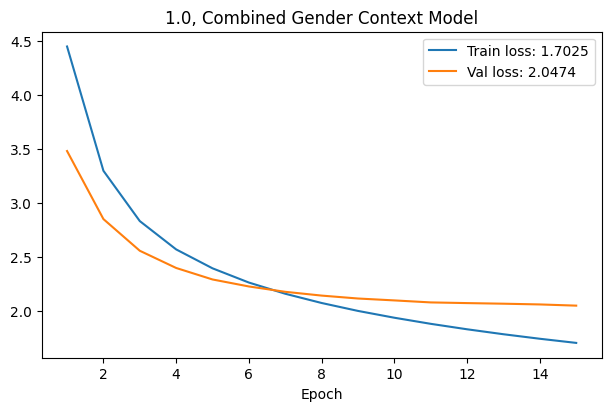

In [25]:
trainer.fit(model, train_data, val_data, 15, '../checkpoints/comb_context-2_0')

In [26]:
with open("../local_data/model_reference/tokenizer_eng_v2.pkl", 'wb') as f:
    pickle.dump(tokenizer_eng, f)

with open("../local_data/model_reference/tokenizer_pol_v2.pkl", 'wb') as f:
    pickle.dump(tokenizer_pol, f)

with open("../local_data/model_reference/encoder_eng_v2", 'wb') as f:
    pickle.dump(encoder_eng, f)

with open("../local_data/model_reference/encoder_pol_v2.pkl", 'wb') as f:
    pickle.dump(encoder_pol, f)